In [ ]:
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from matplotlib.colors import to_hex
from matplotlib.cm import get_cmap

warnings.simplefilter(action='ignore', category=FutureWarning)


df = pd.read_csv("zonas_criticas_electr.csv")
print(df.head())
print(df.columns)

   id_unico            nombre  nombre_municipio  distancia_m_linea_electrica  \
0       175           Cañadas           Castril                 14253.347913   
1       202  Alicún de Ortega  Alicún de Ortega                 15883.050405   
2       302            Gorafe            Gorafe                  9869.134439   
3       303        Los Torres           Castril                 12780.843457   
4       309    Las Vertientes            Cúllar                 16017.092545   

        ccaa provincia  
0  Andalucía   Granada  
1  Andalucía   Granada  
2  Andalucía   Granada  
3  Andalucía   Granada  
4  Andalucía   Granada  
Index(['id_unico', 'nombre', 'nombre_municipio', 'distancia_m_linea_electrica',
       'ccaa', 'provincia'],
      dtype='object')


In [ ]:
# STYLE
sns.set_theme(style="whitegrid", palette="pastel")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 1

In [23]:
# Handle value 99999
import numpy as np
df_clean = df.copy()
df_clean['is_farther_than_20km'] = df_clean['distancia_m_linea_electrica'] == 99999
df_clean['distancia_m_linea_electrica'] = df_clean['distancia_m_linea_electrica'].replace(99999, np.nan)


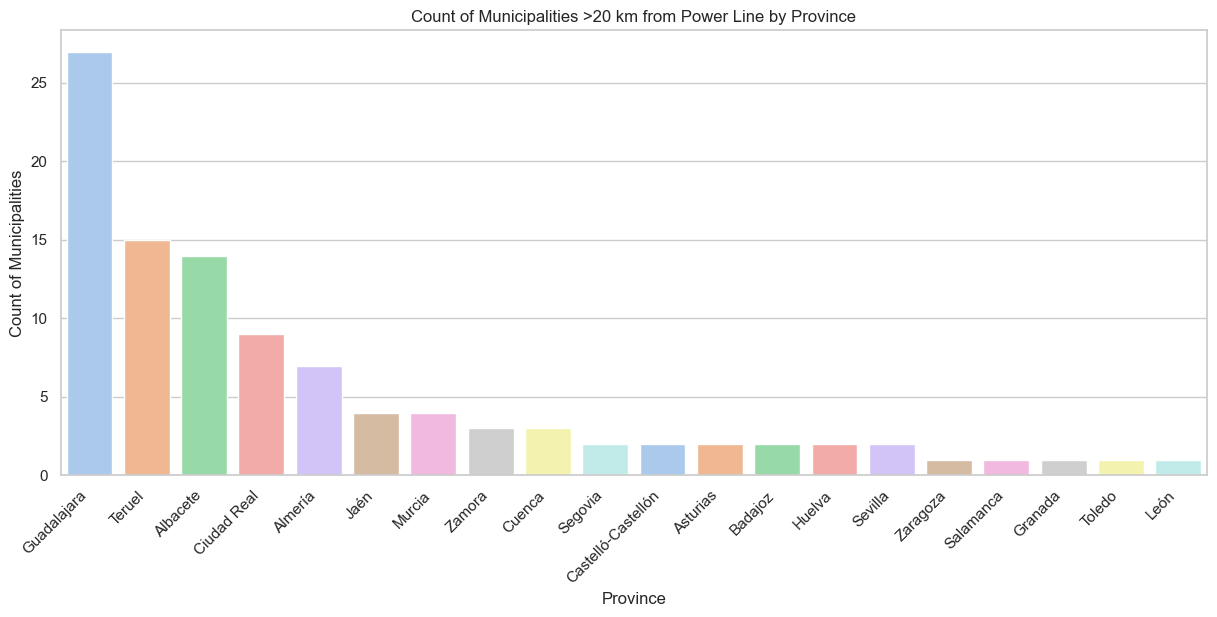

In [36]:
# Filter municipalities where distance is NaN (farther than 20 km)
mask_far = df_clean['distancia_m_linea_electrica'].isna()
df_far = df_clean[mask_far]

# Count how many times each province appears
province_counts = df_far['provincia'].value_counts().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=province_counts.index, y=province_counts.values, palette='pastel')

plt.title('Count of Municipalities >20 km from Power Line by Province')
plt.xlabel('Province')
plt.ylabel('Count of Municipalities')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

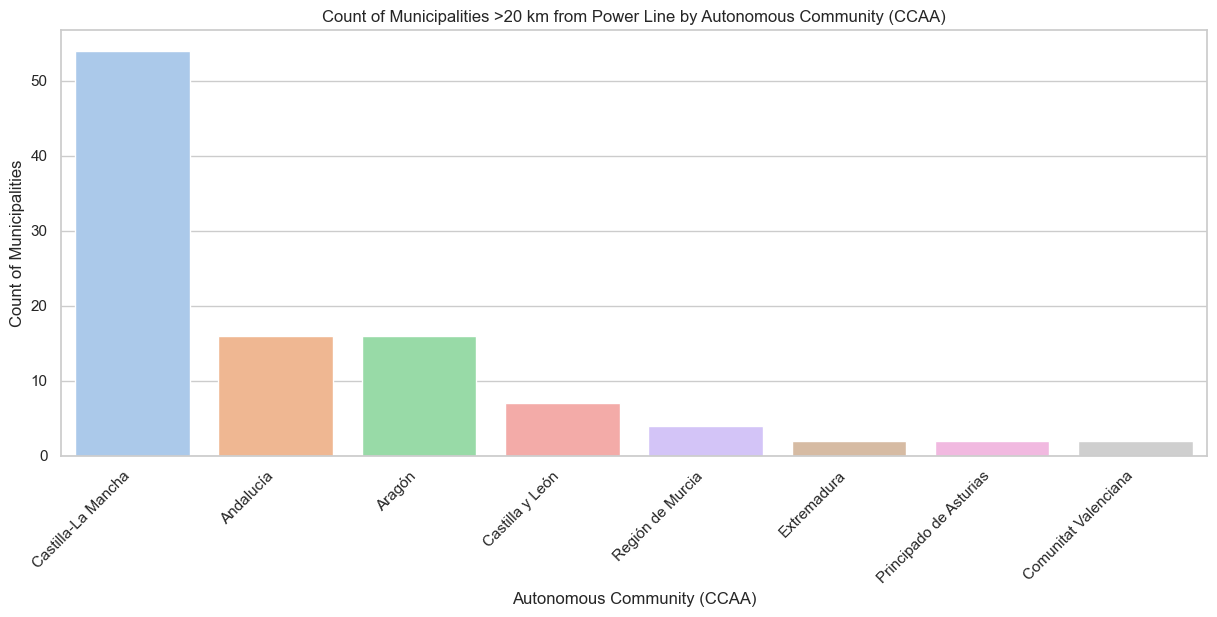

In [37]:
# Filter municipalities where distance is NaN (farther than 20 km)
mask_far = df_clean['distancia_m_linea_electrica'].isna()
df_far = df_clean[mask_far]

# Count how many times each CCAA appears
ccaa_counts = df_far['ccaa'].value_counts().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=ccaa_counts.index, y=ccaa_counts.values, palette='pastel')

plt.title('Count of Municipalities >20 km from Power Line by Autonomous Community (CCAA)')
plt.xlabel('Autonomous Community (CCAA)')
plt.ylabel('Count of Municipalities')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()


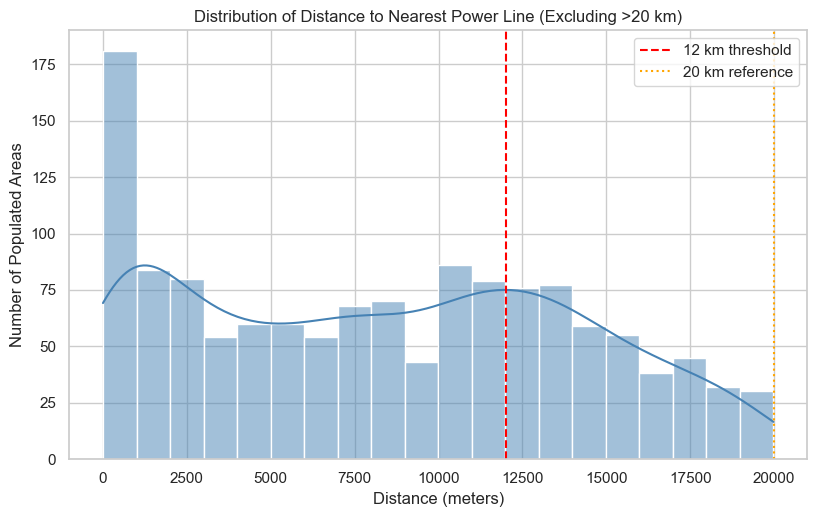

⚠️ 103 populated area(s) are over 20 km from the grid.



In [24]:
plt.figure(figsize=(8, 5))
sns.histplot(df_clean['distancia_m_linea_electrica'], bins=20, kde=True, color='steelblue')
plt.axvline(12000, color='red', linestyle='--', label='12 km threshold')
plt.axvline(20000, color='orange', linestyle=':', label='20 km reference')
plt.title('Distribution of Distance to Nearest Power Line (Excluding >20 km)')
plt.xlabel('Distance (meters)')
plt.ylabel('Number of Populated Areas')
plt.legend()
plt.tight_layout()
plt.show()

excluded_count = df['distancia_m_linea_electrica'].eq(99999).sum()
print(f"⚠️ {excluded_count} populated area(s) are over 20 km from the grid.\n")

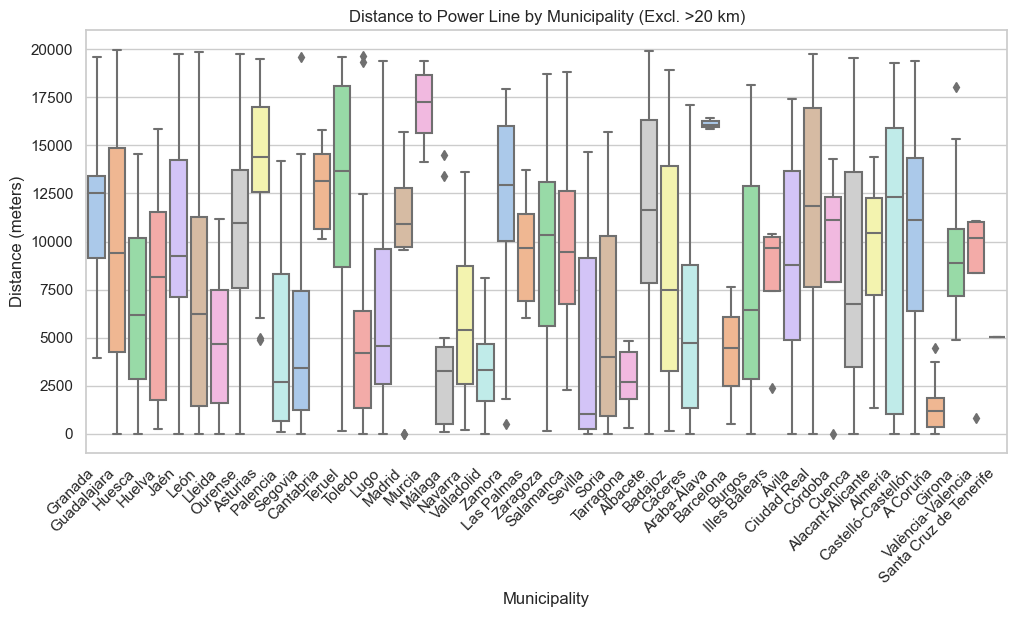

In [25]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_clean,
    x='provincia',
    y='distancia_m_linea_electrica',
    palette='pastel'
)
plt.xticks(rotation=45, ha='right')
plt.title('Distance to Power Line by Municipality (Excl. >20 km)')
plt.ylabel('Distance (meters)')
plt.xlabel('Municipality')
plt.tight_layout()
plt.show()

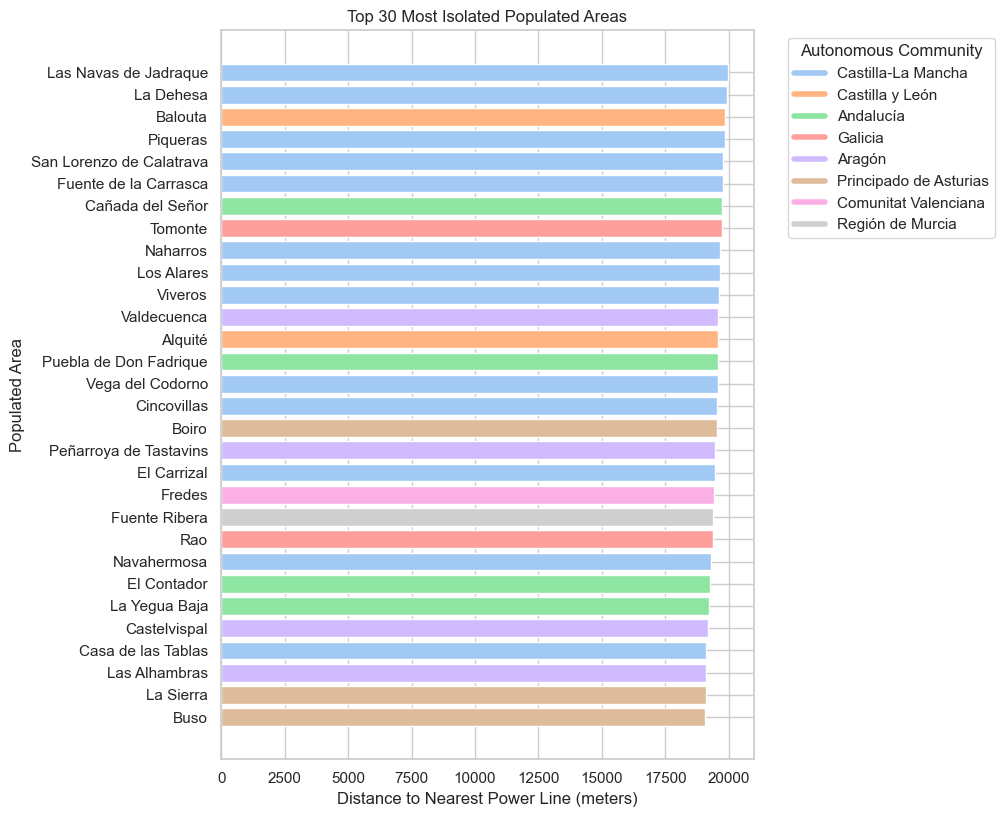

In [ ]:
# Top 30 most isolated populated areas
top_isolated = df_clean.sort_values('distancia_m_linea_electrica', ascending=False).head(30)

# Unique autonomous communities
ccaas = top_isolated['ccaa'].unique()

# pastel palette
pastel_colors = sns.color_palette("pastel", n_colors=len(ccaas))
color_map = {c: to_hex(pastel_colors[i]) for i, c in enumerate(ccaas)}
colors = top_isolated['ccaa'].map(color_map)

# PLOT
plt.figure(figsize=(10, 8))
bars = plt.barh(
    y=top_isolated['nombre'],
    width=top_isolated['distancia_m_linea_electrica'],
    color=colors
)
plt.gca().invert_yaxis()
plt.title('Top 30 Most Isolated Populated Areas')
plt.xlabel('Distance to Nearest Power Line (meters)')
plt.ylabel('Populated Area')
handles = [plt.Line2D([0], [0], color=color_map[c], lw=4) for c in ccaas]
plt.legend(handles, ccaas, title='Autonomous Community', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [40]:

print("Summary of distances (excluding >20 km):\n")
print(df_clean['distancia_m_linea_electrica'].describe())

print(f"\nNumber of populated areas over 20 km from grid: {df_clean['is_farther_than_20km'].sum()}")

Summary of distances (excluding >20 km):

count     1331.000000
mean      8358.669590
std       5756.394778
min          0.000000
25%       2828.067993
50%       8247.009841
75%      13008.131963
max      19978.475895
Name: distancia_m_linea_electrica, dtype: float64

Number of populated areas over 20 km from grid: 103
